# Urban and Rural Climatology and Diurnal Cycle Analysis

This notebook searches for model output files matching a set of user-defined simulation characteristics. For the selected variable, it calculates climatologies of the mean values, daily minima, and daily maxima, distinguishing between urban and rural grid cells defined by a spatial mask. It also computes the urban and rural diurnal cycles, as well as the difference between them.

The file is designed to work with the structure of the already interpolated data.

## Imports
The following libraries and functions are required to run this script.

In [43]:
import os
import sys
import glob
from pathlib import Path

repository_path = str(Path.cwd().parent.resolve())

if repository_path not in sys.path:
    sys.path.insert(0, repository_path)

import numpy as np
import xarray as xr
import xesmf as xe
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from utils.DestinyGridParameters import newlonlat_city
from utils.Urban_Rural_functions import (
    months_or_season,
    variable_rural_urban,
    get_diurnal_cycle,
    get_daily_min_or_max_fields,
    to_curvilinear,
    save_figures,
)

from urclimask.urban_areas import UrbanVicinity
from urclimask.utils import kelvin2degC, fix_360_longitudes

## Variables:
This section defines the target variable, simulation characteristics, city, and its geographical coordinates. The corresponding model domain is selected based on the city, and the matching NetCDF files are located according to the directory structure used in this project. It also defines the data paths, a file containing the official city boundary polygons, the months to be analysed, and the parameters and paths to the static fields required to calculate the urban and rural masks for the selected city. Finally, an empty list is created to store the generated figures. 

The official city boundaries were obtained from the following webpage: 'https://human-settlement.emergency.copernicus.eu/ghs_ucdb_2024.php'. If an updated version becomes available, you can replace the city boundary polygons file by downloading the new file, placing it in the original file directory, and updating the filename in the poligon_info_file variable.

In [44]:
#City name and data info:
variable = 'huss'
driving_model = 'NorESM2-MM'
scenario = 'historical'
member = 'r1i1p1f1'
institution = 'BCCR-UCAN'
model = 'WRF451R-CI4C'
version = 'v1-r1'
time_period = '1hr'
data_version = 'v20240710'
city='Paris'

In [45]:
#City longitude and latitude
if city == 'Paris':
    lon_city = 2.35
    lat_city = 48.86

elif city == 'Barcelona':
    lon_city = 2.17
    lat_city = 41.39

elif city == 'Prague':
    lon_city = 14.42
    lat_city = 50.08

elif city == 'Bergen':
    lon_city = 5.32
    lat_city = 60.39

elif city == 'NewCastle':
    lon_city = -1.62
    lat_city = 54.98

elif city == 'Hamburg':
    lon_city = 9.99
    lat_city = 53.55
else:
    print('The city name is incorrect')

In [46]:
# Obtaination of the domain from the city_name
if city == 'Paris' or city == 'Barcelona' or city == 'Prague':
    # domain = 'ALPX-3i' 
    domain = 'ALPX-3f'#For my data, the current version is called ALPX-3i.
elif city == 'Bergen' or city == 'Hamburg' or city == 'NewCastle':
    domain = 'NSEA-3i'


# Input paths for data and model fields:
data_directory = '../I4C_CPRCM_CITY_DATA/' 
path_input_fields= '../I4C_CPRCM_DATA/'

# Path and file name of the official city boundary polygons file
city_polygon_path = '../utils/'
poligon_info_file = 'city_polygons_clean_file.gpkg'

#Choose the months of the season to analyze (for example, summer months: June, July, August = [6, 7, 8])
season_months = [6, 7, 8]

In [47]:
## Mask configuration

# Mask parameters. Refer to the urclimask documentation for more information.
urban_th = 60
urban_sur_th = 15
orog_diff = 100
sftlf_th = 70
ratio_r2u = 1  # Rural cell number per urban one
min_city_size = 80  # Minimum number of grid points required for the city
lon_lim = 0.7
lat_lim = 0.7

domain_resolution = int(domain.split("-")[1][:-1])  # In km
urban_var = 'sfturf'  # Name of the urban-rural field introduced in the model

#Retrieval of the model input fields
file_sfturf = glob.glob(f"{path_input_fields}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sfturf/{data_version}/*.nc")
file_orog = glob.glob(f"{path_input_fields}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/orog/{data_version}/*.nc")
file_sftlf = glob.glob(f"{path_input_fields}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sftlf/{data_version}/*.nc")


In [48]:
# List to save figures:
figures = [] 

## Mask

### Mask obtention

First, an output directory is created to store the mask files if it does not already exist.

The path and name of the mask file are then defined. The code checks whether a mask already exists for the selected city, domain, and model. If the file exists, it is loaded directly. Otherwise, the urban–rural mask is calculated and saved.

To calculate the mask, the static model fields containing the urban fraction, orography, and land fraction are opened. The `fix_360_longitudes` function from the `urclimask` repository is then applied to these datasets. This function checks whether the longitude coordinates use the 0°–360° or the -180°-180° convention and, when necessary, converts them to the −180°–180° range. Then, the fields are interpolated to the common grid defined for the given city in the I4C project.

Next, an object of the `UrbanVicinity` class is created using the previously defined mask parameters and city information. The static fields are cropped to an area surrounding the selected city, and the intermediate urban, orography, and land-fraction masks are calculated.

The final urban–rural mask is obtained by progressively expanding the area around the city until enough suitable rural grid cells are found. Sea grid cells and areas with non-comparable orography are excluded from the selection.

Finally, the resulting mask is converted into an `xarray.Dataset` and it is saved as a NetCDF file.


In [49]:
#Folder to save masks
output_dir = '../utils/urclimask_Results'# Name of the output directory
os.makedirs(output_dir, exist_ok = True) #The directory is only created if it does'nt exist

In [50]:
path_name_mask = f"{output_dir}/{city}_{domain}_{model}_urban_rural_mask.nc" #Mask file name

# It checks whether the mask exists or not. If it exists, it is read; otherwise, it is calculated.
if os.path.isfile(path_name_mask):
    print("The mask already exists")
    urmask_regridded = xr.open_dataset(path_name_mask)
else:
    #Open fields datasets
    ds_sfturf_0 = xr.open_dataset(file_sfturf[0])
    ds_orog_0 = xr.open_dataset(file_orog[0])
    ds_sftlf_0 = xr.open_dataset(file_sftlf[0])

    ds_sfturf_0 = fix_360_longitudes(ds_sfturf_0)#Repository's urclimask function. It's defined in urclimask/utils.py. 
                                                    #It converts longitudes from 0–360° to -180–180°
    ds_orog_0 = fix_360_longitudes(ds_orog_0)
    ds_sftlf_0 = fix_360_longitudes(ds_sftlf_0)

    ## Target grid for interpolating the model input fields to the common I4C grid:
    #Calculate the I4C grid for the city according the GitHub repository and save the grid parameters:
    new_longitude, new_latitude, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend = newlonlat_city(city) #New_longitude and new_latitude already have the limits expanded 1º

    # Define the target grid as a dataset: Necessary for xESMF regridding
    ds_out = xr.Dataset(coords={ "lon": ("lon", new_longitude), "lat": ("lat", new_latitude)})

    # Source grid of the fields:
    ds_in_mask = xr.Dataset({"lon": ds_sfturf_0["lon"], "lat": ds_sfturf_0["lat"],})

    # Mask-specific regridder
    regridder_mask = xe.Regridder(
                ds_in_mask, ds_out, 
                method="bilinear",
                periodic=False, 
                ignore_degenerate=True)

    # Apply the regridder
    ds_sfturf = regridder_mask(ds_sfturf_0[["sfturf"]])
    ds_orog = regridder_mask(ds_orog_0[["orog"]])
    ds_sftlf = regridder_mask(ds_sftlf_0[["sftlf"]])   

    ds_sfturf = to_curvilinear( ds_sfturf)
    ds_orog  = to_curvilinear(ds_orog)
    ds_sftlf  = to_curvilinear(ds_sftlf)

    #It creates the object urban from UrbanVicinity (urclimask repository)
    URBAN = UrbanVicinity(
                urban_sur_th = urban_sur_th,
                orog_diff = orog_diff,
                sftlf_th = sftlf_th,
                ratio_r2u = ratio_r2u,
                min_city_size = min_city_size,
                lon_city = lon_city,
                lat_city = lat_city,
                lon_lim = lon_lim,
                lat_lim = lat_lim,
                model = model,
                domain = domain,
                urban_th = urban_th,
                urban_var = urban_var
            )

    # # # Crop area around the city in the fields datasets
    ds_sfturf = URBAN.crop_area_city(ds = ds_sfturf, res = domain_resolution)
    ds_orog = URBAN.crop_area_city(ds = ds_orog, res = domain_resolution)
    ds_sftlf = URBAN.crop_area_city(ds = ds_sftlf, res = domain_resolution)

    # Define masks using the parameters above
    sfturf_mask, sfturf_sur_mask, orog_mask, sftlf_mask = URBAN.define_masks(
                ds_sfturf = ds_sfturf, #
                ds_orog = ds_orog, 
                ds_sftlf = ds_sftlf,)

    ## Final rural-urban mask:
    #  Starting from the city, it progressively expands the surrounding area until it finds enough comparable rural cells, 
    # excluding sea, areas with non-comparable orography, and peri-urban zones.
    urmask_regridded = URBAN.select_urban_vicinity(
            sfturf_mask = sfturf_mask, 
            orog_mask = orog_mask,
            sftlf_mask = sftlf_mask,
            sfturf_sur_mask = sfturf_sur_mask)

    # Coordinates assignation:
    urmask_regridded = urmask_regridded.assign_coords( lon=("x", urmask_regridded.lon.isel(y=0).values),
                                                        lat=("y", urmask_regridded.lat.isel(x=0).values)).swap_dims({"x": "lon", "y": "lat"})

    ##Save the mask in a netcdf file:
    urmask_regridded.urmask.to_netcdf(path_name_mask)

    print("The file did not exist, so it was calculated and saved.")

The mask already exists


### Urban–rural mask and official city boundary

First, the file containing the official city boundary polygons is read. The polygon corresponding to the selected city is then extracted and stored in the matches variable.

Next, two colors are assigned to the urban–rural mask: blue for rural grid cells and red for urban grid cells. Since the city boundary and the mask use different coordinate reference systems, the city polygon coordinates are transform to latitude and longitude.

Finally, the urban–rural mask and the official city boundary are represented in the same figure, and the figure is added to the list of generated figures.

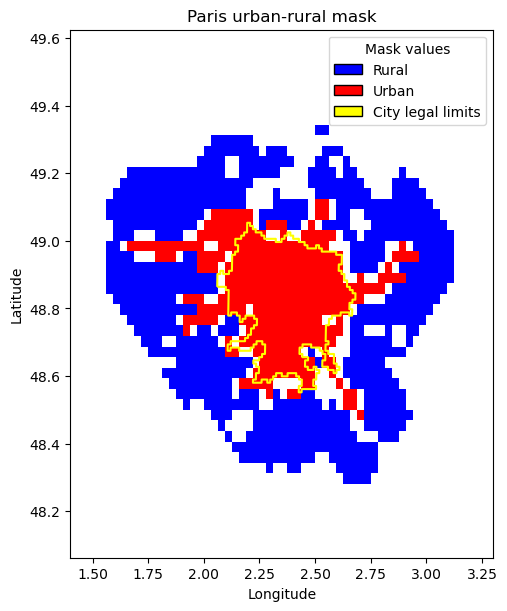

In [51]:
##City poligon extraction:

#Read file
gdf = gpd.read_file(city_polygon_path+poligon_info_file)

#  If the file is updated, you can download the latest version from the official website: 
# https://human-settlement.emergency.copernicus.eu/ghs_ucdb_2024.php

# #clean the geopandas file: Only did it onces.
# Remove \ufeff from colum names
# ucdb_info .columns = [col.lstrip("\ufeff") for col in ucdb_info.columns]
# # Save the clean file:
# ucdb_info .to_file("archivo_limpio.gpkg", driver="GPKG")#to save as geopandas file

#Find the city in the file:
matches = gdf[gdf["GC_UCN_MAI_2025"].astype(str).str.contains(city, case=False, na=False)]


## Mask representation with the polygon: 

# In the mask, 0 corresponds to rural points and 1 to urban points.
# Below, a colour is assigned to each point type.
cmap = ListedColormap(["blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Plot the mask
urmask_regridded.urmask.plot(ax=ax, x="lon", y="lat", cmap=cmap, norm=norm, add_colorbar=False)

# Plot the GeoDataFrame over the mask
matches = matches.to_crs(epsg=4326)
matches.boundary.plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=1.5, zorder=3)

# Set the figure limits depending on the city
if city == 'Paris':
    ax.set_xlim(1.4, 3.3)
elif city == 'Barcelona':
    ax.set_xlim(1.25, 3)
    ax.set_ylim(41, 42.2)
elif city == 'Prague':
    ax.set_xlim(14, 15)
    ax.set_ylim(49.8, 50.4)
    
#Labels and title:
ax.set_title(f"{city} urban-rural mask")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

#Legend:
legend_elements = [
    mpatches.Patch(facecolor="blue", edgecolor="black", label="Rural"),
    mpatches.Patch(facecolor="red", edgecolor="black", label="Urban"),
    mpatches.Patch(facecolor="yellow", edgecolor="black", label="City legal limits")
]
ax.legend(handles=legend_elements, title="Mask values", loc="upper right")

plt.show()
figures.append(fig)

## Heat/hummidity island and diurnal cycles:

In the following section, the data from the input file are analysed for the summer months: June, July, and August (JJA). This is an example, you can change the months studied by changing the numbers from 1 to 12 in the variable season_months defined in the variable section.

First, the variable is averaged over the selected period and represented spatially. The mean diurnal cycles are then calculated separately for the urban and rural areas, along with the difference between them.

Additionally, the fields corresponding to the daily minimum and maximum mean variables are represented. 

### Heat/humidity island and diurnal cycles for the selected months. 

#### Read data:
First, the input dataset is opened. The selected variable is converted from Kelvin to Celsius degrees, and the longitude coordinates are converted from the 0°–360° range to the −180°–180° range when necessary.

The urban–rural mask is then used to separately select the variable values corresponding to urban and rural grid cells.

In [52]:
#Read data
data_path = f'{data_directory}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/'
ds = xr.open_dataset(data_path + variable + '_' + domain + '_' + driving_model + '_' + scenario + '_' + member + '_' + institution + '_' + model + '_' + version + '_' + time_period + '_' + city + '_cropped_interpolated.nc')

#Convert Kelvin degrees to celsius:
ds = kelvin2degC(ds, variable)#K->ºC

#Fix longitudes if it's necessary
ds = fix_360_longitudes(ds)#0–360 -> -180–180

#Selection of urban grid cells:
urban_mask = urmask_regridded.urmask == 1 #Urban mask definition
variable_city = ds[variable].where(urban_mask)

# Selection of the rural grid cells:
rural_mask = urmask_regridded.urmask == 0
variable_rural = ds[variable].where(rural_mask)

#### Summer period selection:

The data corresponding to the summer months ( June, July, and August (JJA) ) are selected separately for the urban and rural grid cells. You can change the months selection in the variable section above (season_months). An attribute specifying the data type is also included in the dataset.

In [53]:
#Obtain the selected months (June, July, August  by default)
print('The selectedmonths are: ', season_months)
season_variable_city = variable_city.sel(time=variable_city.time.dt.month.isin(season_months))
season_variable_rural = variable_rural.sel(time=variable_rural.time.dt.month.isin(season_months))

#Adding the attribute
season_variable_rural.attrs["extreme_type"] = "all data"
season_variable_city.attrs["extreme_type"] = "all data"

The selectedmonths are:  [6, 7, 8]


#### Spatial Representation of Mean Urban and Rural Variable Values 

A figure is generated to show the mean value of the selected variable over the selected period for the urban and rural grid cells. The variable_rural_urban function from Urban_Rural_functions.py is used for this purpose. Within the function, the mean over time is calculated separately for the urban and rural data. Both fields are then represented on the same map using a common colour scale, so that their values can be compared directly. The black line represents the city boundary acoording to the mask. The resulting figure is appended to the list of generated figures.

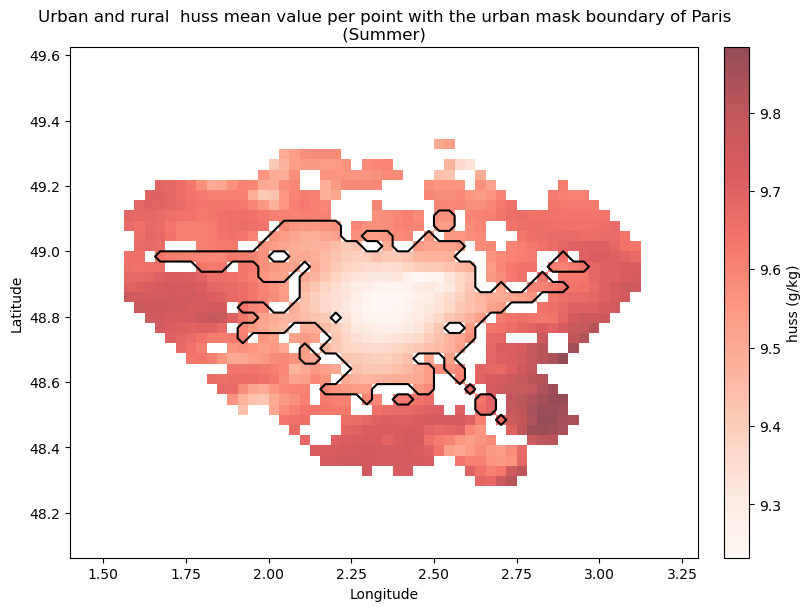

In [54]:

fig=variable_rural_urban(season_variable_city, season_variable_rural, urmask_regridded, variable, city)
figures.append(fig)

#### Diurnal cycle:

The mean diurnal cycles of the selected variable are calculated separately for the urban and rural areas using the get_diurnal_cycle function from Urban_Rural_function.py file.

First, the function calculates the spatial mean over all urban or rural grid cells. The resulting values are then grouped by hour of the day and averaged over the entire summer period. This produces one mean value for each available hour.

Finally, the urban and rural diurnal cycles are represented in the same figure to allow their direct comparison, and the figure is appended to the list of generated figures.

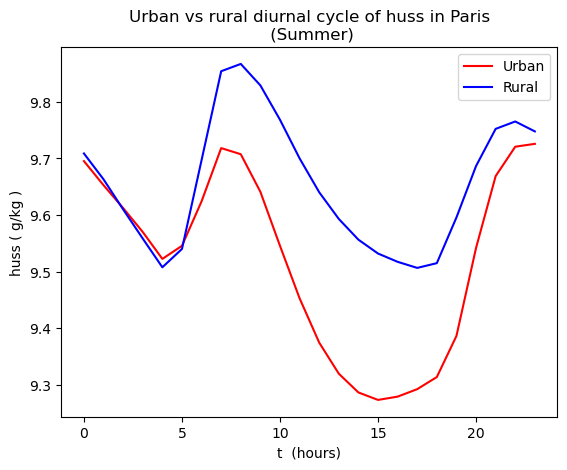

In [55]:
#Obtention of the diurnal cycle for urban and rural areas
season_urban_cycle = get_diurnal_cycle(season_variable_city)
season_rural_cycle = get_diurnal_cycle(season_variable_rural)

#Units:
if variable == 'hurs':
    Variable_units = "% water vapour"
elif variable == 'huss':
    Variable_units = "g/kg"
    season_urban_cycle = season_urban_cycle*1000
    season_rural_cycle = season_rural_cycle*1000 
else:
    Variable_units = urban_file.attrs["units"]  

#Figure
fig, ax = plt.subplots()

season_urban_cycle.plot(ax=ax, label="Urban", color="red")
season_rural_cycle.plot(ax=ax, label="Rural", color="blue")
subtitle = months_or_season(season_months)
ax.set_title(f"Urban vs rural diurnal cycle of {variable} in {city}\n ({subtitle})")
ax.set_xlabel("t  (hours)")
ax.set_ylabel(f"{variable} ( {Variable_units} )")
ax.legend()

figures.append(fig)
plt.show()

The difference between the urban and rural diurnal cycles is then calculated by subtracting the rural cycle from the urban cycle for each hour of the day.

The resulting hourly difference is represented in a separate figure, which shows how the urban–rural difference evolves throughout the mean summer day. Finally, the figure is appended to the list of generated figures.

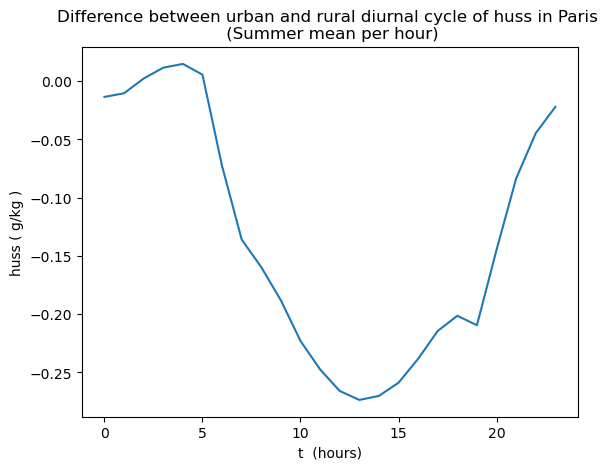

In [56]:
# Difference between urban and rural diurnal cycle:
diurnal_cycle_diff=season_urban_cycle-season_rural_cycle

# Figure:
fig, ax = plt.subplots()
diurnal_cycle_diff.plot(ax=ax)

plt.title(f"Difference between urban and rural diurnal cycle of {variable} in {city} \n ({subtitle} mean per hour)")
ax.set_xlabel("t  (hours)")
ax.set_ylabel(f"{variable} ( {Variable_units} )")

figures.append(fig)
plt.show()

### Daily minimum of the variable for the selected months: heat/humidity island

#### Obtain the minimum variable value 
The daily minimum value along the temporal coordinate (time) is calculated for each spatial point using the get_daily_min_or_max_fields function. An attribute is also added to the DataArray indicating that the values correspond to the daily minimum.

In [57]:
# Daily minimum obtention:
var_min_season_variable_rural = get_daily_min_or_max_fields(season_variable_rural, 'minimum')
var_min_season_variable_city = get_daily_min_or_max_fields(season_variable_city, 'minimum')

#Attribute assignation:
var_min_season_variable_rural.attrs["extreme_type"] = "min"
var_min_season_variable_city.attrs["extreme_type"] = "min"

#### Spatial Representation of Mean Urban and Rural Variable Values
The mean urban and rural fields for the previously selected daily conditions are represented using the variable_rural_urban function. The resulting figure is appended to the list of generated figures.

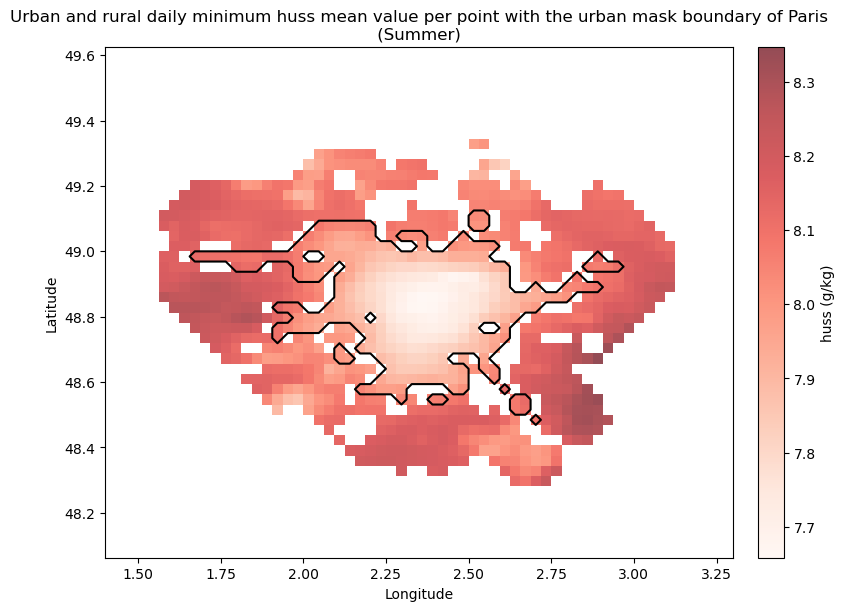

In [58]:
fig=variable_rural_urban(var_min_season_variable_city, var_min_season_variable_rural, urmask_regridded, variable, city)
figures.append(fig)

### Daily maximum of the variable for the selected months: heat/humidity island

#### Obtain the maximum variable values
The maximum value along the temporal coordinate (time) is calculated for each spatial point using the get_daily_min_or_max_fields function. An attribute is also added to the DataArray indicating that the values correspond to the daily maximum.

In [59]:
# Daily minimum obtention:
var_max_season_variable_rural = get_daily_min_or_max_fields(season_variable_rural, 'maximum')
var_max_season_variable_city = get_daily_min_or_max_fields(season_variable_city, 'maximum')

#Attribute assignation:
var_max_season_variable_rural.attrs["extreme_type"] = "max"
var_max_season_variable_city.attrs["extreme_type"] = "max"

#### Spatial Representation of Mean Urban and Rural Variable Values 

The mean urban and rural fields corresponding to the selected daily maximum temperature conditions are represented, and the resulting figure is appended to the list of generated figures.

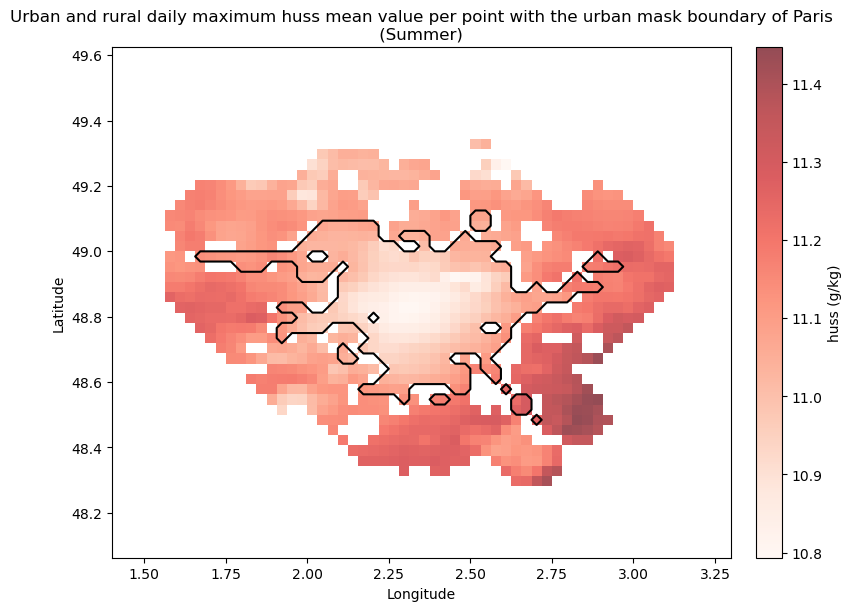

In [60]:
fig=variable_rural_urban(var_max_season_variable_city, var_max_season_variable_rural, urmask_regridded, variable, city)
figures.append(fig)

## Save figures

The figures generated in the previous sections are first assigned to specific positions in a grid. Each figure is associated with a row and a column, which determines its location in the final combined image.

The save_figures function is used to create the final image. This function converts each Matplotlib figure into an image, determines a common cell size, and places the figures in their specified grid positions. Figures smaller than the grid cells are centred within them.

The data directory path is displayed at the bottom of the figure. Finally, the output directory is created if necessary, and the complete image is saved using a file name containing the main information extracted from the input data.

In [61]:
# Use save_figure to save the figures generated in the script.

# Set the position of the figures
positioned_figures = [
         (figures[0], 0, 0),
         (figures[2], 1, 0),
         (figures[3], 2, 0),
         (figures[1], 0, 1),
         (figures[4], 1, 1),
         (figures[5], 2, 1),]

# The following line adds information about the analysed data at the bottom of the figure to help interpret the results.
info_text = (
    f"Files: {data_directory}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/*{city}*.nc\n" 
    # f"Period: {period variable}\n" 
    )

#Path and file name for the final image:
output_dir2 = (Path(f"../mask_climatologies_diurnal_cycle_figures/{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/{city}/"))
output_path = (output_dir2 / f"{variable}_{domain}_{driving_model}_{scenario}_{member}_{institution}_{model}_{version}_{time_period}_mask_climatologies_diurnal_cycle.png")

#The function save_figures is called to create and save the final figure.
combined = save_figures(
    positioned_figures,
    output_path,
    info_text,)